In [776]:
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
import numpy as np
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader
from datetime import datetime
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import Counter
from itertools import product
import math
import hashlib
import io
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import patches
from matplotlib.patches import Patch
import json
from torch.utils.data import TensorDataset

# Model definition

In [777]:
# TODO SET ALL NON USED TO NAN

In [778]:
SEED = 265
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)

In [779]:
IMG_HEIGHT, IMG_WIDTH = 48, 60
DATA_DIR = Path("data")
BATCH_SIZE = 32

In [780]:
EPOCH_INVESTIGATE_POINTS = [2,4,6,8,10]
MAX_EPOCHS = 10

In [781]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cpu.


In [782]:
save_dir = Path("imgs/object_detection")
save_dir.mkdir(parents=True, exist_ok=True)

In [783]:
DO_TRAINING = True  # Set me to TRUE to run training from the start, otherwise we just load existing models

In [784]:
class Preprocessor:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, train_dataset):
        images, _ = train_dataset.tensors

        mean = images.mean(dim=(0, 2, 3))
        std = images.std(dim=(0, 2, 3))

        self.mean = mean
        self.std = std

    def process(self, dataset):
        images, labels = dataset.tensors
        images = (images - self.mean[None, :, None, None]) / self.std[None, :, None, None]
        return TensorDataset(images, labels)

    def unnormalize(self, img):
        img = img.clone()
        img = img * self.std[:, None, None] + self.mean[:, None, None]
        return torch.clamp(img, 0, 1)

In [785]:
# this is loaded to:
# 1. grab images
# 2. grab the actual transformed data, as a sanity check
dataset_train_imgs = torch.load(DATA_DIR / f"detection_train.pt", weights_only = False)
dataset_val_imgs = torch.load(DATA_DIR / f"detection_val.pt", weights_only = False)
dataset_test_imgs = torch.load(DATA_DIR / f"detection_test.pt", weights_only = False)

# we actually use these!
dataset_train = torch.load(DATA_DIR / f"list_y_true_train.pt", weights_only=False)
dataset_val = torch.load(DATA_DIR / f"list_y_true_val.pt", weights_only=False)
dataset_test = torch.load(DATA_DIR / f"list_y_true_test.pt", weights_only=False)

In [ ]:
preprocessor = Preprocessor()
preprocessor.fit(dataset_train_imgs)

dataset_train_imgs = preprocessor.process(dataset_train_imgs)
dataset_val_imgs = preprocessor.process(dataset_val_imgs)
dataset_test_imgs = preprocessor.process(dataset_test_imgs)

Ok so dataset_train_imgs contains images and true 

In [ ]:
print(len(dataset_train))
# looks like a good amount of data

26874


In [ ]:
def global_to_local(x_global, y_global, bb_h, bb_w, rows=2, cols=3, img_cell_plot = False):
    """
    You are supposed to use list_y_true_XXX and preprosessed it.

    In the past, this preprocessing step has been the most difficult part of the project
    and not all have managed to do it.

    Thus, we provide also preprocessed labels in detection_XXX files so that you can do the rest of the detection task even 
    if preprocessing fails. However, if you use these labels, then you lose one point that is given for preprocessing.
    """
    # normalize so each cell has a set width/height

    cell_width = 1 / cols
    cell_height = 1 / rows
    if img_cell_plot:
        cell_width = IMG_WIDTH / cols
        cell_height = IMG_HEIGHT / rows

    # find closest col/width
    col = int(x_global / cell_width)
    row = int(y_global / cell_height)

    # from class lecture
    x_loc = (x_global - col * cell_width) / cell_width
    y_loc = (y_global - row * cell_height) / cell_height

    # bounding boxes
    bb_h_local = bb_h / cell_height
    bb_w_local = bb_w / cell_width

    return [
        x_loc,
        y_loc,
        bb_h_local,
        bb_w_local,
    ]


In [ ]:
# sanity check from class:
global_to_local(0.6,0.6,0.2,0.2, rows=4, cols=3)

[0.8, 0.3999999999999999, 0.8, 0.6000000000000001]

In [ ]:
# sanity check from class:
global_to_local(0.3,0.3,0.3,0.9, rows=4, cols=3)

[0.9, 0.19999999999999996, 1.2, 2.7]

Great, global to local is the same as the ones we computed in class!

Lets check using the pre-computed data

In [ ]:
dataset_train_imgs[0][1][0][0]

tensor([1.0000, 0.7750, 0.8125, 0.3500, 0.7917, 1.0000])

In [ ]:
dataset_train[0][0]

tensor([1.0000, 0.2583, 0.4062, 0.1167, 0.3958, 1.0000])

In [ ]:
y_n, x,y,h,w,cla= dataset_train[0][0]
global_to_local(x,y,h,w)

[tensor(0.7750), tensor(0.8125), tensor(0.2333), tensor(1.1875)]

OK! So global to local works and produces the same output as the preprocessed data. Happy days.

In [ ]:
def scale_vars(x,y,w,h):
    """
    Scale vars to plot correctly
    """
    scaled_x = x*IMG_WIDTH
    scaled_w = w*IMG_WIDTH
    scaled_y = y*IMG_HEIGHT
    scaled_h = h*IMG_HEIGHT

    scaled_x = scaled_x - scaled_w / 2
    scaled_y = scaled_y - scaled_h / 2

    return scaled_x, scaled_y, scaled_w, scaled_h

In [ ]:
def plot_image_boxes(img_pixels, global_coords_ls, ax):
    img = img_pixels.permute(1, 2, 0)

    ax.imshow(img)
    # ax.grid(axis="y")

    rows = 2
    cols = 3
    for r in range(1, rows):
        ax.axhline(y=r*IMG_HEIGHT/rows, color='black', linestyle='--', linewidth=1)
    for c in range(1, cols):
        ax.axvline(x=c*IMG_WIDTH/cols, color='black', linestyle='--', linewidth=1)

    items_in_img = set()

    for coords in global_coords_ls:
        is_item, x, y, w, h, class_label = coords
        items_in_img.add(int(class_label))

        scaled_x, scaled_y, scaled_w, scaled_h = global_to_local(x, y, w, h)

        ax.add_patch(
            patches.Rectangle(
                (scaled_x, scaled_y),
                scaled_w,
                scaled_h,
                linewidth=1,
                edgecolor='r',
                facecolor='none'
            )
        )

    ax.set_title(f"Image with class(es) {items_in_img}, has_item = {int(is_item)}")
    return ax

<Axes: title={'center': 'Image with class(es) {0, 1}, has_item = 1'}>

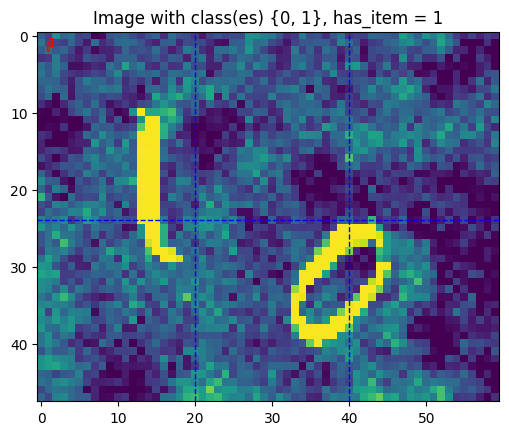

In [ ]:
fig, axes = plt.subplots()

img = dataset_train_imgs[0][0]
global_coords = dataset_train[0]

plot_image_boxes(img, global_coords, axes)

In [ ]:
def plot_image(img_pixels, global_coords_ls, ax):
    img = img_pixels.permute(1, 2, 0)

    ax.imshow(img)

    items_in_img = set()

    for coords in global_coords_ls:
        is_item, x, y, w, h, class_label = coords
        items_in_img.add(int(class_label))

        scaled_x, scaled_y, scaled_w, scaled_h = scale_vars(x, y, w, h)

        ax.add_patch(
            patches.Rectangle(
                (scaled_x, scaled_y),
                scaled_w,
                scaled_h,
                linewidth=1,
                edgecolor='r',
                facecolor='none'
            )
        )

    ax.set_title(f"Image with class(es) {items_in_img}, has_item = {int(is_item)}")
    return ax

<Axes: title={'center': 'Image with class(es) {0, 1}, has_item = 1'}>

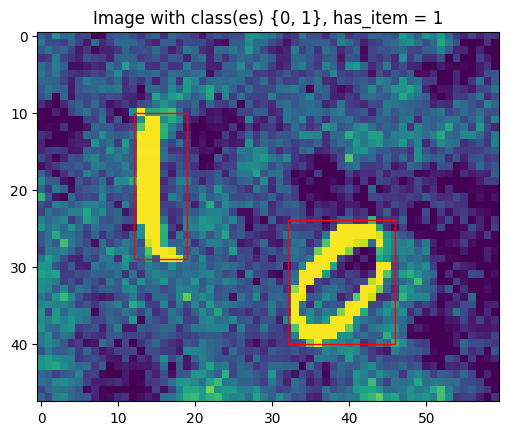

In [ ]:
fig, axes = plt.subplots()

img = dataset_train_imgs[0][0]
global_coords = dataset_train[0]

plot_image(img, global_coords, axes)
# HERE

In [ ]:
# def plot_image_with_prediction(img_tensor, ax, predicted_box: list):
#     """
#     predicted box = [x,y,w,h]
#     """
#     # if ax is None:
#         # make own ax
#     img_pixels = img_tensor[0]
#     is_item, x, y, w, h, class_label = img_tensor[1]

#     img = img_pixels.permute(1, 2, 0)

#     scaled_x, scaled_y, scaled_w, scaled_h = scale_vars(x,y,w,h)

#     ax.imshow(img)
#     ax.add_patch(
#         patches.Rectangle((scaled_x, scaled_y), scaled_w, scaled_h, linewidth=5, edgecolor='r', facecolor='none')
#     )

#     pred_x, pred_y, pred_w, pred_h = predicted_box
#     scaled_x_pred, scaled_y_pred, scaled_w_pred, scaled_h_pred = scale_vars(pred_x,pred_y,pred_w,pred_h)

#     ax.add_patch(
#         patches.Rectangle((scaled_x_pred, scaled_y_pred), scaled_w_pred, scaled_h_pred, linewidth=5, edgecolor='y', facecolor='none')
#     )

#     ax.legend(
#         ["red", "yellow"],
#         ["actual", "predicted"]
#     )

#     ax.set_title(f"Image with class {int(class_label)}, is item = {int(is_item)}")
#     return ax

## Localization


In [ ]:
def non_max_suppresion():
    """todo"""
    ...

    def get_map_results(model, eval_loader, device):
    '''
        Helper functions to get predictions and targets in the format required for mAP calculation.
        Depending on your data processing and model architecture this function can either be used as is, 
        modified to fit your needs or used as a blue print for a rewrite.
        Here it is assussmed that the image has been divide into a 2 x 3 grid.
        ----------------------------------------------------------
        Run through the data in the dataloader and collect predicitions and targets for mAP calculation.

        torchmetric mAP expects predictions and targets in the format:
        preds = [
           { "boxes": tensor([[x1, y1, x2, y2], ...]), "scores": tensor([score1, score2, ...]), "labels": tensor([label1, label2, ...])},
            ...   ]
        and targets = [
            { "boxes": tensor([[x1, y1, x2, y2], ...]), "labels": tensor([label1, label2, ...])},
            ...   ]
        where each dict in the list corresponds to one image in the dataset and contains the predicted and true results
    '''
    model.eval()
    with torch.no_grad():
        preds = []
        targets = []
        for images, labels in eval_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            outputs = outputs.permute(0, 2, 3, 1)                               # (B, 7, 2, 3) → (B, 2, 3, 7)
            outputs = outputs.reshape(outputs.shape[0], -1, outputs.shape[-1])  # (B, 2, 3, 7) → (B, 6, 7)
            labels = labels.reshape(labels.shape[0], -1, labels.shape[-1])      # (B, 2, 3, 6) → (B, 6, 6)
            for output, label in zip(outputs, labels):
                pred_boxes = []
                pred_scores = []
                pred_labels = []
                target_boxes = []
                target_labels = []
                # collect predicted boxes, scores and labels for the current image
                for i, cell_output in enumerate(output):
                    pred_object_presence = (torch.sigmoid(cell_output[0]) > 0.5) * 1.0
                    if pred_object_presence == 1:
                        # get propability of object presence and class probabilities to compute detection score for mAP calculation
                        obj_prop = torch.sigmoid(cell_output[0]).item()
                        class_prop = F.softmax(cell_output[5:], dim=0)
                        pred_label = torch.argmax(class_prop)
                        detect_score = obj_prop * class_prop[pred_label]
                        # convert from local to global coordinates before we can compare with the labels and compute IoU for mAP calculation
                        bbox_global = local_to_global(i // 3, i % 3, cell_output[1:5])
                        bbox_xyxy = xywh_to_xyxy(bbox_global)
                        bbox_xyxy = torch.stack(bbox_xyxy)
                        # collect predicted boxes, scores and labels for the current image
                        pred_boxes.append(bbox_xyxy)
                        pred_scores.append(detect_score)
                        pred_labels.append(pred_label)
                # collect true boxes and labels for the current image
                for i, cell_label in enumerate(label):
                    true_object_presence = cell_label[0]
                    if true_object_presence == 1:
                        bbox_global = local_to_global(i // 3, i % 3, cell_label[1:5])
                        bbox_xyxy = xywh_to_xyxy(bbox_global)
                        bbox_xyxy = torch.stack(bbox_xyxy)
                        target_boxes.append(bbox_xyxy)
                        target_labels.append(int(cell_label[-1]))
                # store predictions and targets for the current image in the format required for mAP calculation
                # if there are no predicted boxes, we need to create an empty tensor for the boxes, scores and labels to avoid errors in the mAP calculation
                if len(pred_boxes) == 0:
                    pred_dict = {
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    }
                    preds.append(pred_dict)
                else:
                    pred_dict = {
                        "boxes": torch.stack(pred_boxes),
                        "scores": torch.tensor(pred_scores, device=device),
                        "labels": torch.tensor(pred_labels, device=device),
                    }
                    preds.append(pred_dict)
                # if there are no true boxes, we need to create an empty tensor for the boxes and labels to avoid errors in the mAP calculation            
                if len(target_boxes) == 0:
                    target_dict = {
                        "boxes": torch.zeros((0, 4), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    }
                    targets.append(target_dict)
                else:
                    target_dict = {
                        "boxes": torch.stack(target_boxes),
                        "labels": torch.tensor(target_labels, device=device),
                    }
                    targets.append(target_dict)

    # compute mAP using torchmetrics
    metric = MeanAveragePrecision(iou_type="bbox")
    metric.update(preds, targets)
    results = metric.compute()
    # results is a dict with the mAP results for different IoU thresholds and the overall mAP
    return results

def local_to_global(i, j, bb, width=60, height=48, cols=3, rows=2):
    x, y, w, h = bb
    # get the dimensions of a single grid cell
    cell_width, cell_height = width / cols, height / rows
    # convert from local to global coordinates
    global_x = x * cell_width + j * cell_width
    global_y = y * cell_height + i * cell_height
    global_w = w * cell_width
    global_h = h * cell_height

    return global_x, global_y, global_w, global_h

def xywh_to_xyxy(bb):
    # convert from center format to box format
    x_center, y_center, w, h = bb
    x1 = x_center - w/2
    y1 = y_center - h/2
    x2 = x_center + w/2
    y2 = y_center + h/2
    return x1, y1, x2, y2


IndentationError: expected an indented block after function definition on line 5 (3296174833.py, line 6)

In [ ]:
"""
How to match y_lists with our output?
we must have some preprocessing...

To which cell should an object go?
Maybe they should be matched to closest cell?

"""
x, y, w, h = bb
# where does it go in our 5*5 volume?
# what we want to do is go from local to global coords
# treat the cell as its own image
# ok where in the cell is our bb?
# use local to global

LOCAL_X = (x - cell_lower_bound) * num_of_cells
LOCAL_Y = (y - cell_lower_bound) * num_of_cells

# your model outputs local coords, but we want global coords!
# transform back!

GLOBAL_X = (x_local / nom_of_cells) + cell_lower_bound

NameError: name 'bb' is not defined

In [ ]:
def localization_loss(y_pred, y_true):
    return torch.where(
        #Todo
        # ...
            # Detection loss
            # ..
            # Bounding box loss
            # ..
            # Classification loss
            # ..
    )

In [ ]:
### .non-max suppression.
post-processing of predictons
what if a number 2 lays betwene 4 squares!

order bb by confidence score (vector[0])

and then we look at class, compute IoU over chosen box vs all other BB of same class.
If it has IoU > 0.5 with this bb, its probably the same, so throw away (supress).

Repeat until all bb are dealt with.

### Load data and preprocessing

In [ ]:
# TODO
# Load the data



### Normalize Images

In [ ]:
# TODO


### Training

same conf = p - (k-1) / 2
dim_new = ((dim_old - k + 2padding) / stride) +1

In [ ]:
class CNNBaseline(nn.Module):
    """
    3 conv into maxpool layers
    """
    def __init__(self):
        super().__init__()
        # if in is 48*40
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1) # dimensions stay the same
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0) # half dimensions 24*20

        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1) # dim stay the same
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride= 2, padding=0) # half dimensions 12*10

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # stays same
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0) # half dimensions 6*5

        self.conv4 = nn.Conv2d(
            # 4*3 filter
            # padding = 1
        ) # dim is 5*5
        self.conv5 = nn.Conv2d(
            # 1*1 filter
            # 15 kernels
        ) # dim is 5*5

        self.fc1 = nn.Linear(32 * 6 * 7, 128)
        self.fc2 = nn.Linear(128, 15)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        # no special output since we are using a custom loss function!
        return x

    def name(self):
        return "CNNBaseline"

### Predictions

In [ ]:
# TODO

## Performance measure

In [ ]:
# num of layers affects size of receptive field
# kernel size affects ability to see complicated things
# we need to use MAP

# we could compute bounding boxes and accuracy

# since we can really have inifnite true negatives, we have to use precision

# precsion : TP / TP + FP <- we can abuse by placing few boxes
# recall : TP / TP + FN <- we can abuse by placing many many boxes

# MAP:
# mean precision is mean precision for one class

# if iou is more than half then we got a TP
# but if multiple, pick the one with highest IOU, rest are FN

### Model selection and evaluation

In [ ]:
def intersection(bb1, bb2):
    """
    Compute intersection between 2 bb, in global frame of ref
    """
    # TODO
   
def IoU(bb1, bb2):
    """
    Compute IoU given 2 bb (local or global)
    """
    #TODO
   
def compute_IoU_localization(model, loader, preprocessor):
    """
    Compute IoU performance of the model on the given dataset
    """
   #TODO

def compute_accuracy_localization(model, loader, preprocessor):
    """
    Compute accuracy of the model on the given dataset
    """
    #TODO
    

In [ ]:
def plot_image_with_prediction(img_tensor, ax, predicted_box: list):
#     """
#     predicted box = [x,y,w,h]
#     """
#     # if ax is None:
#         # make own ax
#     img_pixels = img_tensor[0]
#     is_item, x, y, w, h, class_label = img_tensor[1]

#     img = img_pixels.permute(1, 2, 0)

#     # scaled_x, scaled_y, scaled_w, scaled_h = scale_vars(x,y,w,h)

#     ax.imshow(img)
#     ax.add_patch(
#         patches.Rectangle((x, y), w, h, linewidth=5, edgecolor='r', facecolor='none')
#     )

#     pred_x, pred_y, pred_w, pred_h = predicted_box
#     scaled_x_pred, scaled_y_pred, scaled_w_pred, scaled_h_pred = scale_vars(pred_x,pred_y,pred_w,pred_h)

#     ax.add_patch(
#         patches.Rectangle((scaled_x_pred, scaled_y_pred), scaled_w_pred, scaled_h_pred, linewidth=5, edgecolor='y', facecolor='none')
#     )

#     ax.legend(
#         ["red", "yellow"],
#         ["actual", "predicted"]
#     )

#     ax.set_title(f"Image with class {int(class_label)}, is item = {int(is_item)}")
#     return ax